# CASE STUDY: BELLABEAT

## Table of Contents 

1. Introduction
2. Ask Phase
3. Prepare Phase
4. Process Phase
5. Analyze Phase
6. Share Phase
7. Act Phase

# 1. Introduction
Bellabeat is a wellness-focused tech company that creates beautifully designed smart devices and apps to empower women with insights into their health and habits. The company was founded in 2013 by Urška Sršen and Sando Mur. The Bellabeat app connects with users' smart wellness products to provide users with data on activity, sleep, stress, menstrual cycles, and mindfulness habits, helping them make informed health decisions. By 2016, Bellabeat had expanded globally, offering products through its website and online retailers. The company emphasizes digital marketing through Google Search, social media, YouTube, and the Google Display Network, complemented by traditional advertising such as radio and print, to drive brand awareness and growth.

# 2. Ask Phase
## Business Task
How can Bellabeat use smart device insights to improve its marketing strategy?
## Objective
This project will focus on analyzing data from the Bellabeat app to uncover insights into user habits and preferences. These insights will inform high-level recommendations to optimize Bellabeat's marketing strategy and drive engagement.
## Key Stakeholders
* Urška Sršen: Bellabeat’s cofounder and Chief Creative Officer.
* Sando Mur: Mathematician and Bellabeat’s cofounder; key member of the Bellabeat executive team.

# 3. Prepare Phase
## About the Data
This project will make use of the FitBit Fitness Tracker Data, which is a public domain dataset made available through Mobius. This Kaggle dataset contains personal fitness tracker data from thirty FitBit users. This means that thirty eligible users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring. It includes information about daily activity, steps, and calories that can be used to explore user habits.
## Licensing and Privacy of Data
The dataset does not include personally identifiable information (PII), as it contains aggregated fitness data like activity, heart rate, and sleep patterns. This ensures the privacy of the individuals who provided the data. Furthermore, ethical standards in data analysis have been emphasized by respecting the original intent of the data collection and focusing on aggregated insights rather than individual-level analysis. Lastly, even though the data is anonymized, secure data storage and handling practices have been implemented to prevent unauthorized access or misuse.
## Verification of Data Integrity
The dataset originates from Mobius on Kaggle, a trusted platform, with proper documentation and licensing. Data quality checks are performed to ensure completeness, consistency, and accuracy by identifying missing values, outliers, and logical inconsistencies, and summary statistics are cross-referenced with publicly available benchmarks for validation. Additionally, metadata is reviewed to confirm collection methods, participant details, and alignment with the dataset’s stated purpose. Ethical considerations are also addressed by confirming anonymization, proper participant consent, and adherence to privacy standards, ensuring the dataset is reliable and suitable for analysis.

# 3. Process Phase

In [1]:
#Setting Up Environment

library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Importing Data
To answer our business task, we shall focus on the following variables:
* Daily activity
* Daily steps
* Daily sleep

Since weight and heart rate only provide information for a small number of users, we do not concentrate on these variables.

In [2]:
#Previewing Data

daily_activity<-read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
head(daily_activity)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,4/12/2016,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,4/13/2016,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,4/14/2016,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,4/15/2016,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,4/16/2016,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,4/17/2016,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


In [3]:
daily_steps<-read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailySteps_merged.csv")
head(daily_steps)

,Id,ActivityDay,StepTotal
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016,13162
2,1503960366,4/13/2016,10735
3,1503960366,4/14/2016,10460
4,1503960366,4/15/2016,9762
5,1503960366,4/16/2016,12669
6,1503960366,4/17/2016,9705


In [4]:
daily_sleep<-read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")
head(daily_sleep)

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
,<dbl>,<chr>,<int>,<int>,<int>
1,1503960366,4/12/2016 12:00:00 AM,1,327,346
2,1503960366,4/13/2016 12:00:00 AM,2,384,407
3,1503960366,4/15/2016 12:00:00 AM,1,412,442
4,1503960366,4/16/2016 12:00:00 AM,2,340,367
5,1503960366,4/17/2016 12:00:00 AM,1,700,712
6,1503960366,4/19/2016 12:00:00 AM,1,304,320


## Cleaning Data
After previewing the data, we can proceed with cleaning. This includes checking for errors such as missing values, empty rows or columns, duplicates, and incorrect data types.

In [5]:
#Checking for missing values
#Total missing values
sum(is.na(daily_activity))
sum(is.na(daily_steps))
sum(is.na(daily_sleep))

[1] 0

[1] 0

[1] 0

In [6]:
#Checking for empty rows
empty_rows_activity <- daily_activity[rowSums(is.na(daily_activity)) == ncol(daily_activity), ]
empty_rows_steps<- daily_steps[rowSums(is.na(daily_steps))==ncol(daily_steps), ]
empty_rows_sleep<-daily_sleep[rowSums(is.na(daily_sleep))==ncol(daily_sleep), ]

# Check for empty columns
empty_columns_activity <- daily_activity[, colSums(is.na(daily_activity)) == nrow(daily_activity)]
empty_columns_steps<-daily_steps[, colSums(is.na(daily_steps))==nrow(daily_steps)]
empty_columns_sleep<-daily_sleep[, colSums(is.na(daily_sleep))==nrow(daily_sleep)]

if (nrow(empty_rows_activity) == 0) {
  cat("Empty Rows (Activity): N/A\n")
} else {
  print(empty_rows_activity)
}

Empty Rows (Activity): N/A


In [7]:
#Checking for duplicates
duplicates_daily_activity <- daily_activity[duplicated(daily_activity), ]
cat("Number of duplicate rows in daily_activity:", nrow(duplicates_daily_activity), "\n")

duplicates_daily_steps <- daily_steps[duplicated(daily_steps), ]
cat("Number of duplicate rows in daily_steps:", nrow(duplicates_daily_steps), "\n")

duplicates_daily_sleep <- daily_sleep[duplicated(daily_sleep), ]
cat("Number of duplicate rows in daily_sleep:", nrow(duplicates_daily_sleep), "\n")

Number of duplicate rows in daily_activity: 0 


Number of duplicate rows in daily_steps: 0 


Number of duplicate rows in daily_sleep: 3 


In [8]:
#Removing duplicates
daily_sleep <- daily_sleep[!duplicated(daily_sleep), ]

cat("Number of duplicate rows in daily_sleep:", nrow(duplicates_daily_sleep), "\n")

Number of duplicate rows in daily_sleep: 3 


In [9]:
#Confirming duplicates have been removed
duplicates_daily_sleep <- daily_sleep[duplicated(daily_sleep), ]
cat("Number of duplicate rows in daily_sleep:", nrow(duplicates_daily_sleep), "\n")

Number of duplicate rows in daily_sleep: 0 


In [10]:
#Checking for incorrect data types
str(daily_activity)
str(daily_steps)
str(daily_sleep)

'data.frame':	940 obs. of  15 variables:
 $ Id                      : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ ActivityDate            : chr  "4/12/2016" "4/13/2016" "4/14/2016" "4/15/2016" ...
 $ TotalSteps              : int  13162 10735 10460 9762 12669 9705 13019 15506 10544 9819 ...
 $ TotalDistance           : num  8.5 6.97 6.74 6.28 8.16 ...
 $ TrackerDistance         : num  8.5 6.97 6.74 6.28 8.16 ...
 $ LoggedActivitiesDistance: num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveDistance      : num  1.88 1.57 2.44 2.14 2.71 ...
 $ ModeratelyActiveDistance: num  0.55 0.69 0.4 1.26 0.41 ...
 $ LightActiveDistance     : num  6.06 4.71 3.91 2.83 5.04 ...
 $ SedentaryActiveDistance : num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveMinutes       : int  25 21 30 29 36 38 42 50 28 19 ...
 $ FairlyActiveMinutes     : int  13 19 11 34 10 20 16 31 12 8 ...
 $ LightlyActiveMinutes    : int  328 217 181 209 221 164 233 264 205 211 ...
 $ SedentaryMinutes        : int  728 776 1218 726 773 539 

'data.frame':	940 obs. of  3 variables:
 $ Id         : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ ActivityDay: chr  "4/12/2016" "4/13/2016" "4/14/2016" "4/15/2016" ...
 $ StepTotal  : int  13162 10735 10460 9762 12669 9705 13019 15506 10544 9819 ...


'data.frame':	410 obs. of  5 variables:
 $ Id                : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ SleepDay          : chr  "4/12/2016 12:00:00 AM" "4/13/2016 12:00:00 AM" "4/15/2016 12:00:00 AM" "4/16/2016 12:00:00 AM" ...
 $ TotalSleepRecords : int  1 2 1 2 1 1 1 1 1 1 ...
 $ TotalMinutesAsleep: int  327 384 412 340 700 304 360 325 361 430 ...
 $ TotalTimeInBed    : int  346 407 442 367 712 320 377 364 384 449 ...


In [11]:
#Converting character columns to dates
daily_activity_ActivityDate <- as.Date(daily_activity$ActivityDate, format = "%m/%d/%Y")
daily_steps_ActivityDay<-as.Date(daily_steps$ActivityDay,format="%m/%d/%Y")
daily_sleep_SleepDay<-as.Date(daily_sleep$SleepDay,format="%m/%d/%Y")

In [12]:
#Confirming successful conversion of character columns to dates
str(daily_activity)
str(daily_steps)
str(daily_sleep)

'data.frame':	940 obs. of  15 variables:
 $ Id                      : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ ActivityDate            : chr  "4/12/2016" "4/13/2016" "4/14/2016" "4/15/2016" ...
 $ TotalSteps              : int  13162 10735 10460 9762 12669 9705 13019 15506 10544 9819 ...
 $ TotalDistance           : num  8.5 6.97 6.74 6.28 8.16 ...
 $ TrackerDistance         : num  8.5 6.97 6.74 6.28 8.16 ...
 $ LoggedActivitiesDistance: num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveDistance      : num  1.88 1.57 2.44 2.14 2.71 ...
 $ ModeratelyActiveDistance: num  0.55 0.69 0.4 1.26 0.41 ...
 $ LightActiveDistance     : num  6.06 4.71 3.91 2.83 5.04 ...
 $ SedentaryActiveDistance : num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveMinutes       : int  25 21 30 29 36 38 42 50 28 19 ...
 $ FairlyActiveMinutes     : int  13 19 11 34 10 20 16 31 12 8 ...
 $ LightlyActiveMinutes    : int  328 217 181 209 221 164 233 264 205 211 ...
 $ SedentaryMinutes        : int  728 776 1218 726 773 539 

'data.frame':	940 obs. of  3 variables:
 $ Id         : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ ActivityDay: chr  "4/12/2016" "4/13/2016" "4/14/2016" "4/15/2016" ...
 $ StepTotal  : int  13162 10735 10460 9762 12669 9705 13019 15506 10544 9819 ...


'data.frame':	410 obs. of  5 variables:
 $ Id                : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ SleepDay          : chr  "4/12/2016 12:00:00 AM" "4/13/2016 12:00:00 AM" "4/15/2016 12:00:00 AM" "4/16/2016 12:00:00 AM" ...
 $ TotalSleepRecords : int  1 2 1 2 1 1 1 1 1 1 ...
 $ TotalMinutesAsleep: int  327 384 412 340 700 304 360 325 361 430 ...
 $ TotalTimeInBed    : int  346 407 442 367 712 320 377 364 384 449 ...


After successfully checking and fixing the dataset's errors, we now proceed to the last part of our cleaning phase, which is cleaning column names. Here, we first load the necessary packages required. These are the 'janitor' and 'dplyr' packages.

In [13]:
#Loading necessary packages for cleaning column names
library(janitor)
library(dplyr)


Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [14]:
#Cleaning column names
daily_activity<-daily_activity%>%clean_names()
daily_steps<-daily_steps%>%clean_names()
daily_sleep<-daily_sleep%>%clean_names()

#Viewing updated column names
colnames(daily_activity)
colnames(daily_steps)
colnames(daily_sleep)

[1] "id"                         "activity_date"             
 [3] "total_steps"                "total_distance"            
 [5] "tracker_distance"           "logged_activities_distance"
 [7] "very_active_distance"       "moderately_active_distance"
 [9] "light_active_distance"      "sedentary_active_distance" 
[11] "very_active_minutes"        "fairly_active_minutes"     
[13] "lightly_active_minutes"     "sedentary_minutes"         
[15] "calories"

[1] "id"           "activity_day" "step_total"

[1] "id"                   "sleep_day"            "total_sleep_records" 
[4] "total_minutes_asleep" "total_time_in_bed"

Having successfully cleaned the column names, the data cleaning process is complete. We are ready to move on to the analysis and sharing phase.

# 4. Analyze and Share Phase
With the data cleaned and prepared, the next step is to integrate the three datasets into a single unified table.We merge the datasets to create a unified table that combines the key information from `daily_activity`, `daily_steps`, and `daily_sleep`. This integration enables a comprehensive analysis by linking activity, step count, and sleep data for each user on a specific date. By merging these datasets, we can identify patterns, correlations, and trends across multiple aspects of users' behavior, which would not be possible if the data remained fragmented.
### Merging the Datasets
First, the `daily_activity` and `daily_steps` datasets are merged using the `id` and their respective date columns (`activity_date` and `activity_day`)..

In [15]:
#Merging the daily_activity and daily_steps datasets
activity_steps_merged <- merge(daily_activity, daily_steps, 
                               by.x = c("id", "activity_date"), 
                               by.y = c("id", "activity_day"), 
                               all = TRUE)

#Keep one clean steps column
activity_steps_merged <- activity_steps_merged %>%
mutate (
    total_steps = coalesce (total_steps, step_total,0)
    )%>%
select (-step_total)

# Preview merged table
head(activity_steps_merged)

,id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,4/12/2016,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,4/13/2016,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,4/14/2016,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,4/15/2016,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,4/16/2016,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,4/17/2016,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


Next, the resulting merged dataset is combined with the `daily_sleep` dataset using the `id` and `activity_date` columns. This step integrates all three datasets into a unified table for analysis.

In [16]:
# Standardize dates
activity_steps_merged <- activity_steps_merged %>%
  mutate(activity_date = as.Date(activity_date))

daily_sleep <- daily_sleep %>%
  mutate(sleep_day = as.Date(sleep_day))

#Summarise sleep per day
daily_sleep_clean <- daily_sleep %>%
  mutate(sleep_day = as.Date(sleep_day)) %>%
  group_by(id, sleep_day) %>%
  summarise(
    total_minutes_asleep = sum(total_minutes_asleep, na.rm = TRUE),
    total_time_in_bed = sum(total_time_in_bed, na.rm = TRUE),
    .groups = "drop"
  )

#Join tables
merged_data <- activity_steps_merged %>%
  inner_join(
    daily_sleep_clean,
    by = c("id", "activity_date" = "sleep_day")
  )

#Preview merged table
head(merged_data)

,id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,total_minutes_asleep,total_time_in_bed
,<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1503960366,4-12-20,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,327,346
2,1503960366,NA,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,5249,5591
3,1503960366,NA,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776,5249,5591
4,1503960366,NA,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,5249,5591
5,1503960366,NA,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,5249,5591
6,1503960366,NA,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728,5249,5591


We generate summary statistics from the dataset to examine key metrics, identify patterns, and uncover trends that highlight user habits related to activity, sleep, and calorie burn. This step provides a foundation for deriving meaningful insights and informing subsequent analyses.

In [17]:
summary(merged_data)

       id            activity_date      total_steps    total_distance  
 Min.   :1.504e+09   Min.   :4-12-20   Min.   :    0   Min.   : 0.000  
 1st Qu.:2.347e+09   1st Qu.:5-02-20   1st Qu.: 3973   1st Qu.: 2.672  
 Median :4.559e+09   Median :5-06-20   Median : 7878   Median : 5.535  
 Mean   :4.844e+09   Mean   :5-06-09   Mean   : 7785   Mean   : 5.511  
 3rd Qu.:6.962e+09   3rd Qu.:5-09-20   3rd Qu.:11030   3rd Qu.: 7.822  
 Max.   :8.792e+09   Max.   :5-12-20   Max.   :22988   Max.   :17.950  
                     NA's   :431                                       
 tracker_distance logged_activities_distance very_active_distance
 Min.   : 0.000   Min.   :0.0000             Min.   : 0.000      
 1st Qu.: 2.672   1st Qu.:0.0000             1st Qu.: 0.000      
 Median : 5.535   Median :0.0000             Median : 0.320      
 Mean   : 5.494   Mean   :0.1427             Mean   : 1.437      
 3rd Qu.: 7.800   3rd Qu.:0.0000             3rd Qu.: 2.240      
 Max.   :17.950   Max.   :4.

### Daily Steps Analysis
Here, we categorize users based on the number of steps taken. We also calculate the average, minimum, and maximum daily steps for all users.
Step categories include:

    Very Active: 10,000 steps and above.
    Fairly Active: Between 7,500 and 9,999 steps.
    Lightly Active: Between 5,000 and 7,499 steps.
    Sedentary: Less than 5,000 steps.

In [18]:
# Calculate avg, min and max daily steps for all users
summary(merged_data$total_steps)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0    3973    7878    7785   11030   22988 

In [19]:
# Categorize users based on step count and add step_category column to dataset
merged_data <- merged_data %>%
  mutate(
    step_category = factor(
      case_when(
        total_steps >= 10000 ~ "Very Active",
        total_steps >= 7500 & total_steps < 10000 ~ "Fairly Active",
        total_steps >= 5000 & total_steps < 7500 ~ "Lightly Active",
        total_steps < 5000 ~ "Sedentary",
        TRUE ~ NA_character_
      ),
      levels = c("Sedentary", "Lightly Active", "Fairly Active", "Very Active")
    )
  )
# Check distribution of Step Categories
head(merged_data)

,id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,total_minutes_asleep,total_time_in_bed,step_category
,<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,1503960366,4-12-20,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,327,346,Very Active
2,1503960366,NA,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,5249,5591,Very Active
3,1503960366,NA,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776,5249,5591,Very Active
4,1503960366,NA,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,5249,5591,Fairly Active
5,1503960366,NA,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,5249,5591,Very Active
6,1503960366,NA,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728,5249,5591,Fairly Active


In [20]:
# Calculate proportions of users in each step category
step_category_prop <- merged_data %>%
  filter(!is.na(step_category)) %>%
  group_by(step_category) %>%
  summarise(Count = n(), .groups = "drop") %>%
  mutate(Proportion = round((Count / sum(Count)) * 100, 2))

print(step_category_prop)

# A tibble: 4 × 3
  step_category  Count Proportion
  <fct>          <int>      <dbl>
1 Sedentary        186       31.5
2 Lightly Active    97       16.4
3 Fairly Active    100       17.0
4 Very Active      207       35.1



Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor




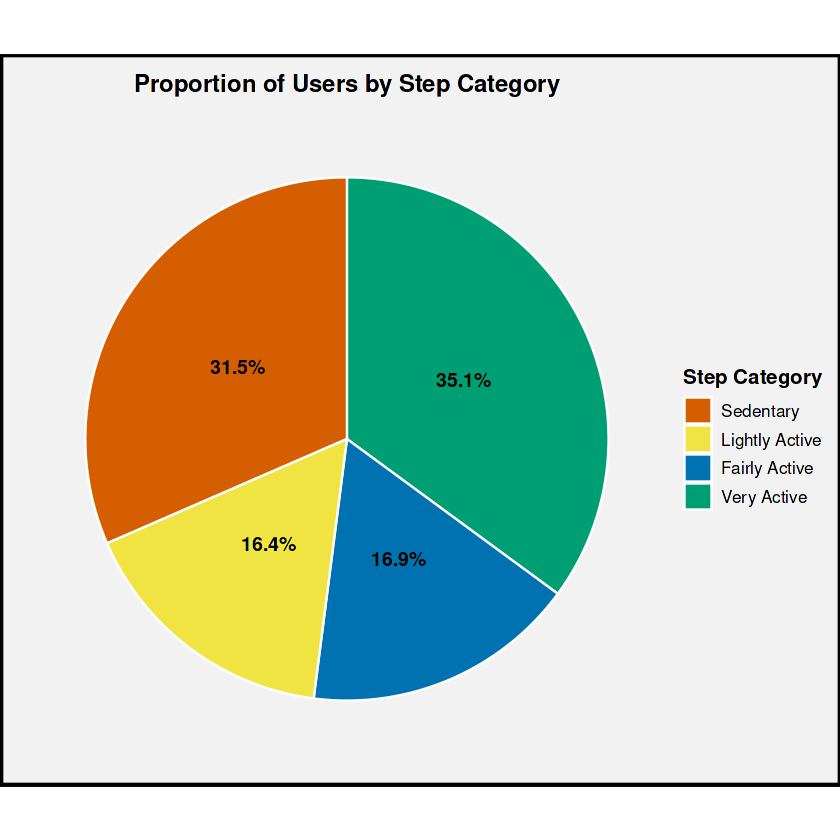

In [21]:
# Pie Chart for Step Categories
library(ggplot2)
library(dplyr)
library(ggrepel)
library(scales)

# Calculate Proportion of Users bt Step Category
df <- step_category_prop %>%
 #filter(!is.na(step_category)) %>%   #  removes NA rows to remove section
  mutate(
    pct = (Proportion / 100)
  ) %>%
  arrange(desc(pct)) %>%
  mutate(
    label = scales::percent(pct, accuracy = 0.1),
    csum = cumsum(pct),
    ypos = csum - pct / 2
  )

palette <- c(
  "Sedentary" = "#D55E00",
  "Lightly Active" = "#F0E442",
  "Fairly Active" = "#0072B2",
  "Very Active" = "#009E73"
)

ggplot(df, aes(x = 1, y = pct, fill = step_category)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y", start = 0) +
  geom_text(aes(label = label),
            position = position_stack(vjust = 0.5),
            color = "black",
            fontface = "bold",
            size = 4,
            show.legend = FALSE)  +
  scale_fill_manual(values = palette) +
  labs(
    title = "Proportion of Users by Step Category",
    fill = "Step Category"
  ) +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 8)),
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 10),
    plot.background = element_rect(color = "black", fill = "#F2F2F2", linewidth = 1.2),
    panel.border = element_blank(),
    plot.margin = margin(12, 12, 12, 12)
  )

### Distance vs Calorie Burn
This includes the total and average very_active_distance, light_active_distance, and moderately_active_distance. In this case, we compare users at various distances with their calorie burn by step category in order to analyze activity intensity.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


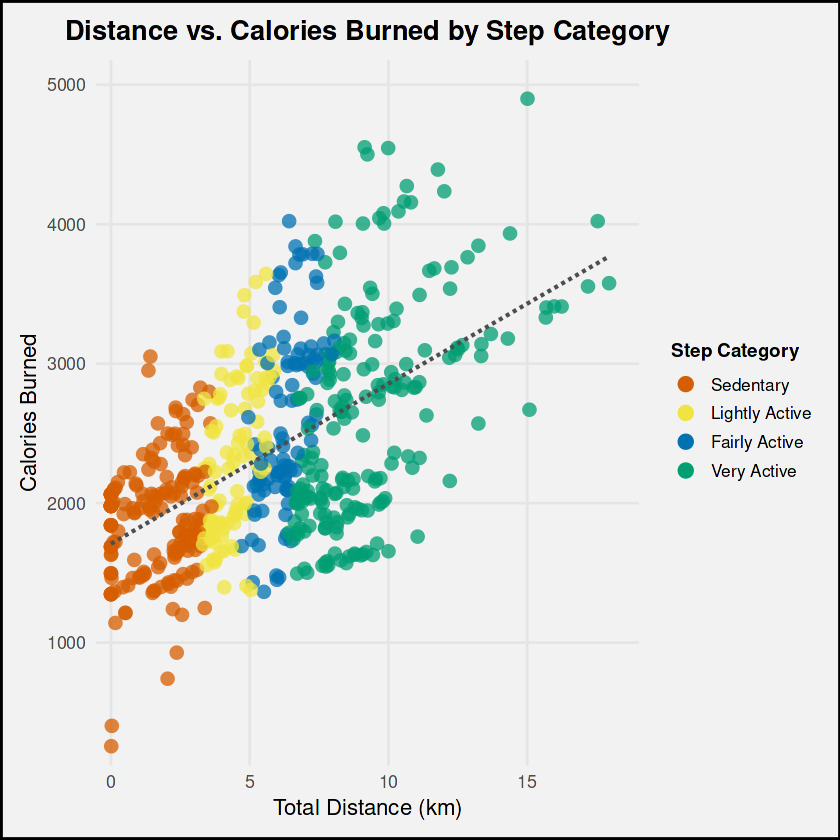

In [22]:
# Plot Distance vs. Calories Burned by Step Category
library(ggplot2)

palette <- c(
  "Sedentary" = "#D55E00",
  "Lightly Active" = "#F0E442",
  "Fairly Active" = "#0072B2",
  "Very Active" = "#009E73"
)

ggplot(merged_data, aes(x = total_distance, y = calories, color = step_category)) +
  geom_point(alpha = 0.75, size = 3.5, shape = 16) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "grey30", linetype = "dashed", size = 0.9) +
  scale_color_manual(values = palette) +
  labs(
    title = "Distance vs. Calories Burned by Step Category",
    x = "Total Distance (km)",
    y = "Calories Burned",
    color = "Step Category"
  ) +
  scale_x_continuous(expand = expansion(mult = c(0.03, 0.06))) +
  scale_y_continuous(expand = expansion(mult = c(0.03, 0.06))) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold", margin = margin(b = 8)),
    legend.position = "right",
    legend.title = element_text(size = 11, face = "bold"),
    legend.text = element_text(size = 10),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = "#F2F2F2", color = NA),
    plot.background = element_rect(color = "black", fill = "#F2F2F2", size = 1),
    plot.margin = margin(12, 12, 12, 12)
  ) +
  guides(color = guide_legend(override.aes = list(size = 4, alpha = 1)))

### Key Observations:
1. **Positive Correlation**: There is a clear positive relationship between distance traveled and calories burned. As users cover more distance, they tend to burn more calories.
   
2. **Step Categories**:
   - **Sedentary** (red): These users generally show the lowest distances traveled and calories burned, clustered toward the bottom-left.
   - **Lightly Active** (yellow): These points show a moderate increase in both distance and calorie burn compared to sedentary users.
   - **Fairly Active** (blue): Users in this category display a higher range of distance and calorie burn, indicating increased activity levels.
   - **Very Active** (purple): These users cover the highest distances and burn the most calories, with points extending farthest along both axes.

3. **Spread Within Categories**: Each step category shows some spread in calorie burn for similar distances, likely influenced by factors like body weight, age, and exercise intensity.

### Insights:
- The plot emphasizes the role of physical activity in increasing calorie expenditure.
- Encouraging users to move from lower activity categories (e.g., Sedentary) to higher ones (e.g., Fairly or Very Active) can lead to substantial improvements in calories burned and overall fitness.
- Additional factors (e.g., pace, incline) might explain variations in calorie burn for similar distances within a step category.

### Calories Burned vs Active Minutes
This comprises the average and total number of calories burned by each user. We correlate calorie burn with active minutes to better understand user participation in physical activities.

In [23]:
#Calculate Average Calories and Active Minutes per Step Category
summary_stats <- merged_data %>%
filter(!is.na(step_category)) %>%
  group_by(step_category) %>%
  summarize(
    AvgCaloriesBurned = mean(calories, na.rm = TRUE),
    AvgActiveMinutes = mean(very_active_minutes + fairly_active_minutes + lightly_active_minutes, na.rm = TRUE)
  )

print(summary_stats)

# A tibble: 4 × 3
  step_category  AvgCaloriesBurned AvgActiveMinutes
  <fct>                      <dbl>            <dbl>
1 Sedentary                  1878.             102.
2 Lightly Active             2311.             250.
3 Fairly Active              2597.             293.
4 Very Active                2647.             317.


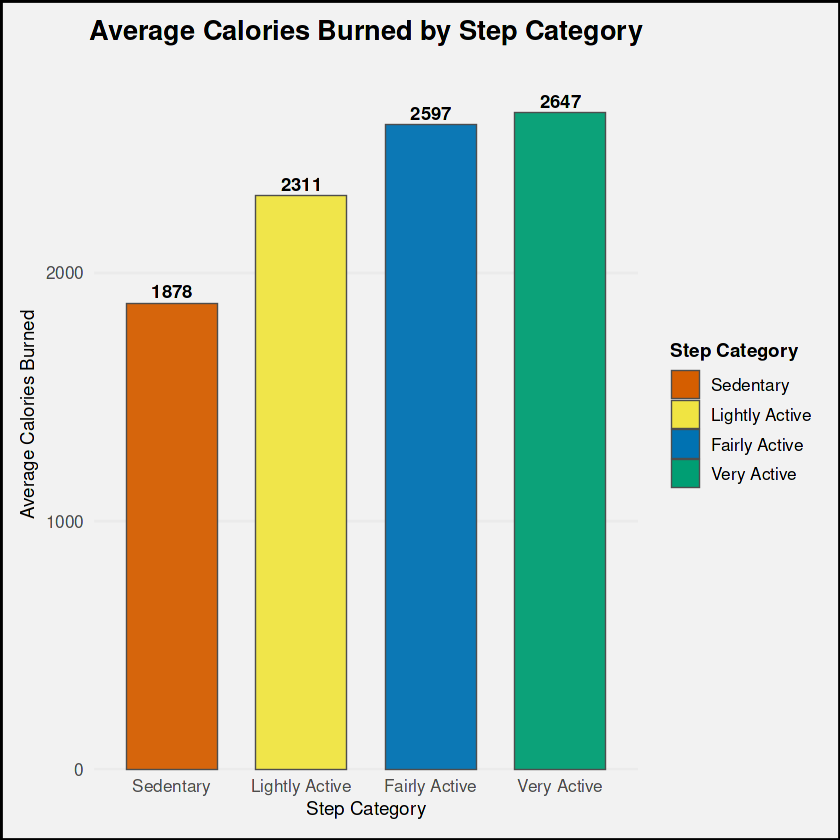

In [24]:
#Calories Burned vs Active Minutes by Step Category

library(ggplot2)
library(scales)

palette <- c(
  "Sedentary" = "#D55E00",
  "Lightly Active" = "#F0E442",
  "Fairly Active" = "#0072B2",
  "Very Active" = "#009E73"
)

ggplot(summary_stats, aes(x = step_category, y = AvgCaloriesBurned, fill = step_category)) +
  geom_col(width = 0.7, alpha = 0.95, color = "grey30", size = 0.3) +
  scale_fill_manual(values = palette) +
  geom_text(aes(label = round(AvgCaloriesBurned, 0)), 
            vjust = -0.35, size = 3.8, color = "black", fontface = "bold") +
  labs(
    title = "Average Calories Burned by Step Category",
    x = "Step Category",
    y = "Average Calories Burned",
    fill = "Step Category"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold", margin = margin(b = 8)),
    axis.title.x = element_text(size = 11),
    axis.title.y = element_text(size = 11),
    axis.text = element_text(size = 10),
    legend.position = "right",
    legend.title = element_text(size = 11, face = "bold"),
    legend.text = element_text(size = 10),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = NA, color = NA),
    plot.background = element_rect(color = "black", fill = "#F2F2F2", size = 1),
    plot.margin = margin(12, 12, 12, 12)
  ) +
  guides(fill = guide_legend(override.aes = list(alpha = 1, size = 6)))

### Key Observations:
1. **Sedentary Users**: Users in this category burned the fewest average calories, which is expected due to low physical activity levels.
   
2. **Lightly and Fairly Active Users**: These categories show a moderate increase in average calories burned compared to sedentary users, reflecting increased physical activity.

3. **Very Active Users**: This category burned the highest average calories, demonstrating a direct correlation between high activity levels and calorie expenditure.

### Insights:
This chart effectively illustrates the relationship between physical activity and energy expenditure. It emphasizes how higher step counts (indicative of more activity) significantly impact the number of calories burned, which can inform recommendations for users aiming to improve fitness or manage weight.

### Sleep Duration
Here, we analyze the average, minimum, and maximum values for total_minutes_asleep and total_time_in_bed to understand user sleep patterns. Additionally, we assess how many users meet the recommended 7-9 hours of sleep daily by comparing total_time_in_bed vs total_minutes_asleep.

In [25]:
# Summary of Sleep Duration
summary(merged_data$total_minutes_asleep)
summary(merged_data$total_time_in_bed)

# Proportion of users with recommended sleep duration
prop_good_sleep <- mean(merged_data$total_minutes_asleep >= 420 & merged_data$total_minutes_asleep <= 540, na.rm = TRUE)
cat("Proportion of users with recommended sleep duration:", round(prop_good_sleep * 100, 2), "%\n")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   58.0   401.8  1335.0  3306.4  6002.0  8516.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   61.0   437.2  1414.0  3613.1  7370.0  9288.0 

Proportion of users with recommended sleep duration: 12.37 %


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


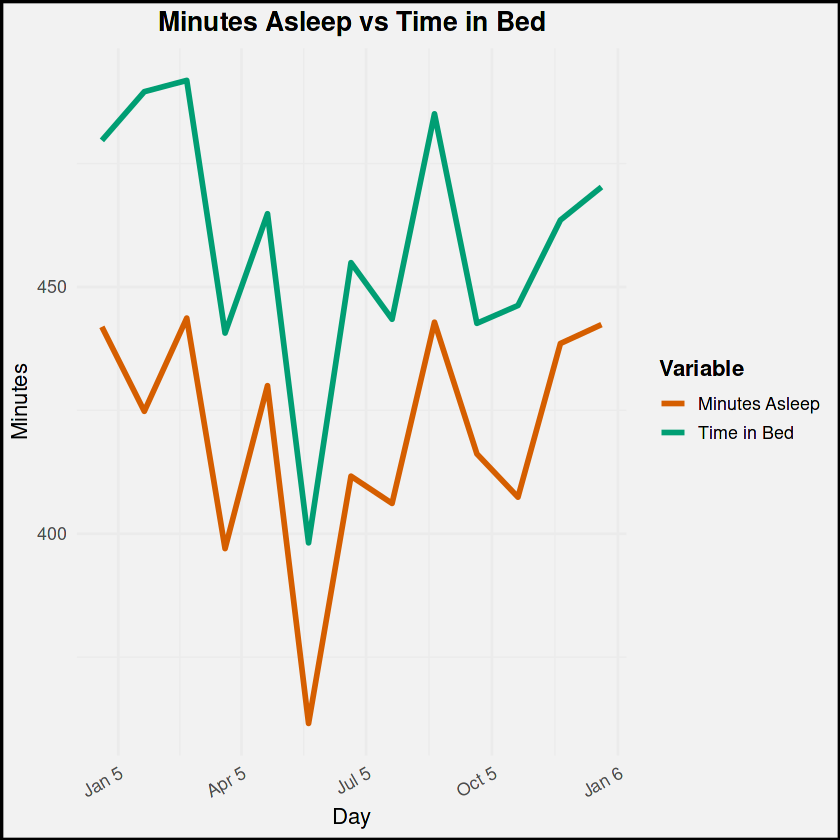

In [26]:
# Plot Minutes Asleep vs Time in Bed
library(ggplot2)
library(dplyr)
library(lubridate)
library(scales)

# Aggregate Variables Per Day
df <- daily_sleep %>%
  mutate(sleep_day = as.Date(sleep_day)) %>%
  group_by(sleep_day) %>%
  summarise(
    total_minutes_asleep = mean(total_minutes_asleep, na.rm = TRUE),
    total_time_in_bed = mean(total_time_in_bed, na.rm = TRUE)
  ) %>%
  arrange(sleep_day)

# Plot Line Graph
ggplot(df, aes(x = sleep_day)) +
  geom_line(aes(y = total_minutes_asleep, color = "Minutes Asleep"), linewidth = 1.2) +
  geom_line(aes(y = total_time_in_bed, color = "Time in Bed"), linewidth = 1.2) +
  labs(
    title = "Minutes Asleep vs Time in Bed",
    x = "Day",
    y = "Minutes",
    color = "Variable"
  ) +
  scale_color_manual(values = c(
    "Minutes Asleep" = "#D55E00",
    "Time in Bed" = "#009E73"
  )) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    
    # Light grey background & border
    plot.background = element_rect(fill = "#F2F2F2", color = "black", linewidth = 1.2),
    
    # Legend styling
    legend.position = "right",
    legend.title = element_text(face = "bold"),
    
    # Axis readability
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

### Key Observations:
1. **Not all time in bed is sleep:** 
   - The teal line (time in bed) consistently sits above the red line (minutes asleep), showing users spend nontrivial time awake while in bed. This gap reflects time spent awake while in bed, such as winding down before sleep or waking during the night.

2. **Consistent positive relationship with variability:**
   - Longer time in bed generally corresponds to more minutes asleep, but the gap size varies across observations. That means increasing time in bed tends to increase sleep, but not proportionally for everyone.

3. **Patterns shift across time:**
   - Both sleep and time in bed rise and fall over different months, suggesting that lifestyle, routines, or seasonal factors may influence sleep behavior.

### Insights:
- Overall, the chart shows that while more time in bed generally leads to more sleep, the difference between the two lines highlights that quality and efficiency are just as important as duration. Fluctuations across time suggest that external factors, such as daily routines or seasonal changes, play a role in shaping sleep patterns.

### Relationship Between Activity and Sleep
Analysing the relationship between activity levels and sleep quality helps identify how physical activity impacts rest. This relationship can offer insights into promoting better sleep habits through increased activity, aligning with Bellabeat's goal of improving user wellness.

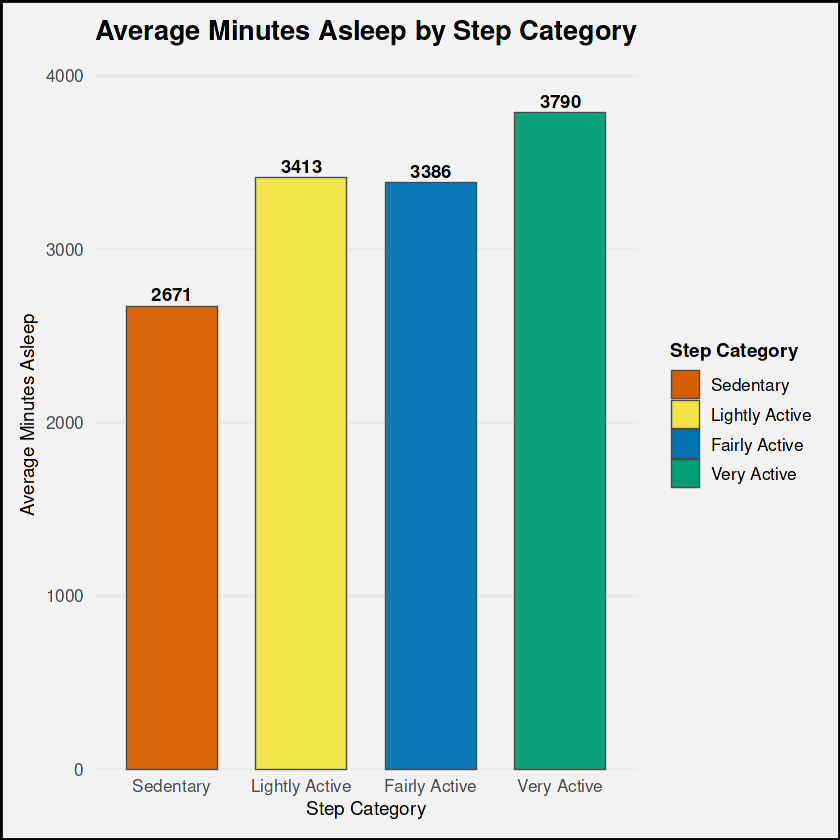

In [27]:
#Plot Average Minutes Asleep by Step Category
library(dplyr)
library(ggplot2)
library(scales)

# Palette (consistent styling)
palette <- c(
  "Sedentary" = "#D55E00",
  "Lightly Active" = "#F0E442",
  "Fairly Active" = "#0072B2",
  "Very Active" = "#009E73"
)

# Order categories
merged_data$step_category <- factor(
  merged_data$step_category,
  levels = c("Sedentary", "Lightly Active", "Fairly Active", "Very Active")
)

# Calculate Average Minutes Asleep
df_summary <- merged_data %>%
  group_by(step_category) %>%
  summarise(
    avg_minutes_asleep = mean(total_minutes_asleep, na.rm = TRUE),
    .groups = "drop"
  )

# Plot bar graph
ggplot(df_summary, aes(x = step_category, y = avg_minutes_asleep, fill = step_category)) +
  geom_col(width = 0.7, alpha = 0.95, color = "grey30", size = 0.3) +
  scale_fill_manual(values = palette) +
  geom_text(
    aes(label = round(avg_minutes_asleep, 0)),
    vjust = -0.35,
    size = 3.8,
    color = "black",
    fontface = "bold"
  ) +
  labs(
    title = "Average Minutes Asleep by Step Category",
    x = "Step Category",
    y = "Average Minutes Asleep",
    fill = "Step Category"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(
      hjust = 0.5,
      size = 16,
      face = "bold",
      margin = margin(b = 8)
    ),
    axis.title.x = element_text(size = 11),
    axis.title.y = element_text(size = 11),
    axis.text = element_text(size = 10),
    legend.position = "right",
    legend.title = element_text(size = 11, face = "bold"),
    legend.text = element_text(size = 10),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = NA, color = NA),
    plot.background = element_rect(color = "black", fill = "#F2F2F2", size = 1),
    plot.margin = margin(12, 12, 12, 12)
  ) +
  guides(fill = guide_legend(override.aes = list(alpha = 1, size = 6)))

`geom_smooth()` using formula = 'y ~ x'


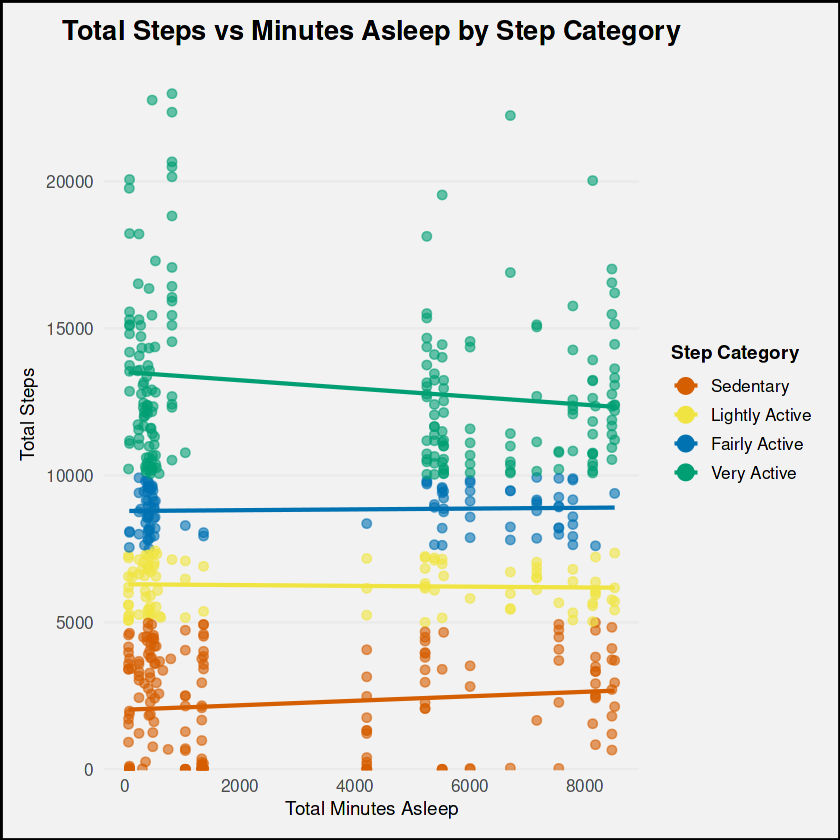

In [28]:
# Scatter Plot for Total Steps vs Minutes Asleep by Category
library(ggplot2)
library(scales)

palette <- c(
  "Sedentary" = "#D55E00",
  "Lightly Active" = "#F0E442",
  "Fairly Active" = "#0072B2",
  "Very Active" = "#009E73"
)

ggplot(merged_data, aes(
  x = total_minutes_asleep,
  y = total_steps,
  color = step_category
)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(
    method = "lm",
    se = FALSE,
    aes(group = step_category, color = step_category),
    linewidth = 0.9
  ) +
  scale_color_manual(values = palette) +
  labs(
    title = "Total Steps vs Minutes Asleep by Step Category",
    x = "Total Minutes Asleep",
    y = "Total Steps",
    color = "Step Category"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(
      hjust = 0.5,
      size = 16,
      face = "bold",
      margin = margin(b = 8)
    ),
    axis.title.x = element_text(size = 11),
    axis.title.y = element_text(size = 11),
    axis.text = element_text(size = 10),

    legend.position = "right",
    legend.title = element_text(size = 11, face = "bold"),
    legend.text = element_text(size = 10),

    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),

    panel.background = element_rect(fill = NA, color = NA),
    plot.background = element_rect(color = "black", fill = "#F2F2F2", size = 1),

    plot.margin = margin(12, 12, 12, 12)
  ) +
  guides(color = guide_legend(override.aes = list(size = 4, alpha = 1)))

In [29]:
# Calculate Correlation between Sleep and Activity
# Correlation for Very Active
cor_very_active_steps <- cor(
  merged_data$total_minutes_asleep[merged_data$step_category == "Very Active"],
  merged_data$total_steps[merged_data$step_category == "Very Active"],
  use = "complete.obs"
)

# Correlation for Fairly Active
cor_fairly_active_steps <- cor(
  merged_data$total_minutes_asleep[merged_data$step_category == "Fairly Active"],
  merged_data$total_steps[merged_data$step_category == "Fairly Active"],
  use = "complete.obs"
)

# Correlation for Lightly Active
cor_lightly_active_steps <- cor(
  merged_data$total_minutes_asleep[merged_data$step_category == "Lightly Active"],
  merged_data$total_steps[merged_data$step_category == "Lightly Active"],
  use = "complete.obs"
)

# Correlation for Sedentary
cor_sedentary_steps <- cor(
  merged_data$total_minutes_asleep[merged_data$step_category == "Sedentary"],
  merged_data$total_steps[merged_data$step_category == "Sedentary"],
  use = "complete.obs"
)

# Print results
print(paste("Correlation between sleep and very active steps:", round(cor_very_active_steps, 2)))
print(paste("Correlation between sleep and fairly active steps:", round(cor_fairly_active_steps, 2)))
print(paste("Correlation between sleep and lightly active steps:", round(cor_lightly_active_steps, 2)))
print(paste("Correlation between sleep and sedentary steps:", round(cor_sedentary_steps, 2)))

[1] "Correlation between sleep and very active steps: -0.17"


[1] "Correlation between sleep and fairly active steps: 0.06"


[1] "Correlation between sleep and lightly active steps: -0.06"


[1] "Correlation between sleep and sedentary steps: 0.13"


### Key Observations:
1. **Average Minutes Asleep by Step Category:**
   - On average, more active categories sleep longer.
   - The bar chart shows that fairly and very active groups have higher mean sleep minutes compared to sedentary or lightly active groups. This suggests a broad association between activity and sleep duration.

2. **Total Steps vs Minutes Asleep by Step Category:**
   - Averages mask variability. The scatter plot reveals wide differences within each category. Even among very active individuals, sleep minutes vary substantially, and the trend lines are relatively flat. This means step counts don’t strongly predict sleep at the individual level. 

3. **Correlation Between Sleep and Activity:**
   - Correlations confirm weak relationships. The correlation coefficients are close to zero (ranging from -0.17 to +0.13), indicating that physical activity levels alone are not strong predictors of sleep in this dataset.

In hindsight, while activity levels are distinct among categories, sleep duration remains relatively independent of activity level. This insight can guide Bellabeat to focus on personalizing marketing strategies for activity-based goals rather than sleep patterns alone.

# 5. Act Phase
Our goal is to determine how marketing strategies can be enhanced by smart device insights, specifically from the Bellabeat app. Further research with larger datasets is encouraged, as our sample size was small and did not account for factors such as geographical location.

### Recommendations to Optimize Bellabeat’s Marketing Strategy and Drive Engagement  

#### **1. Sleep Duration**  
- **Trend Utilization:** Integrate wearable device sleep tracking with actionable insights, leveraging the popularity of personalized health recommendations.  
- **App Enhancements:**  
  - Add a feature to detect sleep irregularities and provide customized suggestions like mindfulness exercises or stress-reduction activities.  
  - Develop a "Sleep Coach" tool that uses AI to predict and recommend optimal bedtime routines.  
- **Marketing Strategy:**  
  - Promote Bellabeat’s ability to improve sleep hygiene through targeted campaigns emphasizing its smart device integration and data-backed solutions.  

#### **2. Distance vs. Calorie Burn**  
- **Trend Utilization:** Highlight fitness motivation trends by motivating users to increase activity levels.  
- **App Enhancements:**  
  - Incorporate progress tracking challenges (e.g., step milestones or distance goals) with badges and rewards.  
  - Include personalized calorie-burn goals based on user fitness levels and activity history.  
- **Marketing Strategy:**  
  - Position Bellabeat app as a fitness companion with real-time tracking and motivational features. Use testimonials and success stories in campaigns.  

#### **3. Calorie Burned vs. Active Minutes**  
- **Trend Utilization:** Capitalize on the demand for real-time feedback and AI-driven fitness predictions.  
- **App Enhancements:**  
  - Develop predictive calorie-burn analytics using AI to help users plan workouts effectively.  
  - Add visual data comparisons showing how increased activity impacts calorie burn over time.  
- **Marketing Strategy:**  
  - Use interactive advertisements showcasing the app’s ability to track, analyze, and predict calorie burn to appeal to fitness enthusiasts and weight management audiences.  

#### **4. Activity and Sleep Insights**  
- **Trend Utilization:** Leverage data-driven personalization to appeal to users looking for integrated health insights.  
- **App Enhancements:**  
  - Introduce comparative dashboards that link sleep quality and activity levels to stress and wellness.  
  - Provide weekly summaries showing correlations between user habits (activity, sleep, stress).  
- **Marketing Strategy:**  
  - Segment users into activity-focused and sleep-focused groups for personalized campaigns. Highlight the app’s ability to provide holistic health insights.  

#### **5. Mindfulness and Stress Management**  
- **Trend Utilization:** Tap into the growing mindfulness movement and rising demand for stress management tools.  
- **App Enhancements:**  
  - Add guided meditation sessions or breathing exercises based on real-time stress detection.  
  - Integrate mood-tracking features linked to activity and sleep data to personalize wellness tips.  
- **Marketing Strategy:**  
  - Create campaigns focusing on the app's unique integration of stress detection, mindfulness, and health tracking tools. Highlight the app’s proactive stress-reduction features.  

#### **6. Emerging Trends in Smart Device Usage**  
- **Focus Areas:**  
  - **Wearable Compatibility:** Ensure compatibility with emerging wearable devices, such as smart rings and glasses, to expand user reach.  
  - **Sustainability Focus:** Develop eco-friendly wearable devices and market them as part of Bellabeat’s commitment to wellness and sustainability.  
  - **Social Connectivity:** Incorporate social sharing features for fitness milestones and mindfulness habits to boost app visibility through user engagement.  

These recommendations aim to improve Bellabeat app's functionality, increase marketing effectiveness, and drive user engagement and satisfaction by aligning its features with emerging smart device usage trends and leveraging insights from user behavior data.